In [1]:
from final_data import titanic_data, titanic_test_data, titanic_gender_submission
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

In [2]:
data = titanic_data()
X = data[['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked',
       'Gender', 'FareGroup', 'AgeGroup', 'FamilySize', 'FarePerPerson', 'IsAlone']]
y = data['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=19)

In [3]:
print(X_train.dtypes)

Pclass              int64
Age               float64
SibSp               int64
Parch               int64
Fare              float64
Embarked           object
Gender             object
FareGroup        category
AgeGroup         category
FamilySize          int64
FarePerPerson     float64
IsAlone             int64
dtype: object


In [4]:
numeric_features = [
    'Pclass',
    'Age',
    'SibSp',
    'Parch',
    'Fare',
    'FamilySize',
    'FarePerPerson',
    'IsAlone'
]

categorical_features = [
    'Embarked',
    'Gender',
    'FareGroup',
    'AgeGroup'
]

In [5]:
preprocessor = ColumnTransformer([
    ('numeric', StandardScaler(), numeric_features),
    ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

pipe_line = Pipeline([
    ('preprocessor', preprocessor),
    ('gradientboosting', GradientBoostingClassifier())
], verbose=True)

pipe_line.fit(X_train, y_train)

[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .. (step 2 of 2) Processing gradientboosting, total=   0.3s


,steps,"[('preprocessor', ...), ('gradientboosting', ...)]"
,transform_input,None
,memory,None
,verbose,True
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [6]:
param_grid = {
    'gradientboosting__loss': ['log_loss', 'exponential'],
    'gradientboosting__ccp_alpha': [0, 0.001, 0.01],
    'gradientboosting__max_depth': [3, 6, 8],
    'gradientboosting__n_estimators': [80, 100, 150],
    'gradientboosting__max_features': ['sqrt', 'log2', None],
    'gradientboosting__max_leaf_nodes': [3, 5, 7]
}

In [7]:
grid = GridSearchCV(estimator=pipe_line, param_grid=param_grid, cv=5, verbose=1, scoring='accuracy')
grid.fit(X_train, y_train)

Fitting 5 folds for each of 486 candidates, totalling 2430 fits
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .. (step 2 of 2) Processing gradientboosting, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .. (step 2 of 2) Processing gradientboosting, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .. (step 2 of 2) Processing gradientboosting, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .. (step 2 of 2) Processing gradientboosting, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .. (step 2 of 2) Processing gradientboosting, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] .. (step 2 of 2) Processing gradientboosting, total=   0.1s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] ..

,estimator,Pipeline(step... verbose=True)
,param_grid,"{'gradientboosting__ccp_alpha': [0, 0.001, ...], 'gradientboosting__loss': ['log_loss', 'exponential'], 'gradientboosting__max_depth': [3, 6, ...], 'gradientboosting__max_features': ['sqrt', 'log2', ...], ...}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('numeric', ...), ('categorical', ...)]"


In [8]:
grid.best_params_

{'gradientboosting__ccp_alpha': 0.001,
 'gradientboosting__loss': 'exponential',
 'gradientboosting__max_depth': 8,
 'gradientboosting__max_features': 'sqrt',
 'gradientboosting__max_leaf_nodes': 7,
 'gradientboosting__n_estimators': 150}

In [9]:
grid.best_score_

np.float64(0.8195229576624925)

In [10]:
test_data = titanic_test_data()
gender_submission_data = titanic_gender_submission()
X_test = test_data[['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked',
       'Gender', 'FareGroup', 'AgeGroup', 'FamilySize', 'FarePerPerson', 'IsAlone']]
y_test = gender_submission_data['Survived']

In [11]:
test_accuracy = grid.score(X_test, y_test)
test_accuracy

0.861244019138756

In [12]:
pred = grid.predict(X_test)

print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))

[[245  21]
 [ 37 115]]
              precision    recall  f1-score   support

           0       0.87      0.92      0.89       266
           1       0.85      0.76      0.80       152

    accuracy                           0.86       418
   macro avg       0.86      0.84      0.85       418
weighted avg       0.86      0.86      0.86       418



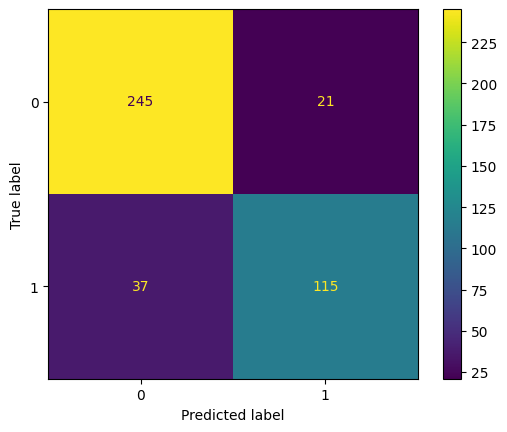

In [13]:
ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, pred), display_labels=grid.classes_).plot()